In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Prepare the Iris Dataset

In [ ]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y_raw = iris.target

# One-hot encode the target
y = to_categorical(y_raw, 3)

print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)
print("Features:", iris.feature_names)

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Manual implementation of ReLU
def relu(x):
    return np.maximum(0, x)

# Manual implementation of Leaky ReLU
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

values = np.array([-5, -2, -1, 0, 1, 2, 5])

comparison = pd.DataFrame({
    "Input": values,
    "ReLU": relu(values),
    "Leaky ReLU": leaky_relu(values)
})

comparison

,Input,ReLU,Leaky ReLU
0,-5,0,-0.05
1,-2,0,-0.02
2,-1,0,-0.01
3,0,0,0.00
4,1,1,1.00
5,2,2,2.00
6,5,5,5.00


## 4. Visualize ReLU vs Leaky ReLU

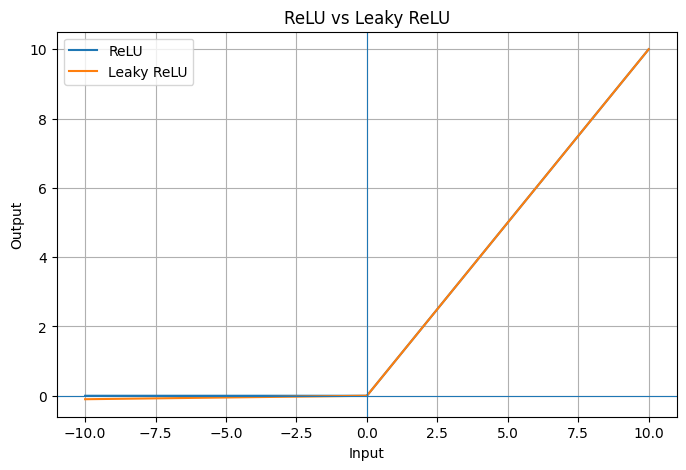

In [ ]:
x = np.linspace(-10, 10, 400)

relu_values = relu(x)
lrelu_values = leaky_relu(x)

plt.figure(figsize=(8, 5))
plt.plot(x, relu_values, label="ReLU")
plt.plot(x, lrelu_values, label="Leaky ReLU")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("ReLU vs Leaky ReLU")
plt.legend()
plt.grid()
plt.show()

## 5. Create Neural Network Models


In [ ]:
def create_model(activation="relu"):
    model = Sequential()

    # First hidden layer
    model.add(Dense(16, input_shape=(4,)))

    if activation == "relu":
        model.add(Dense(16, activation="relu"))
    else:
        model.add(Dense(16))
        model.add(LeakyReLU(negative_slope=0.01))

    # Second hidden layer
    model.add(Dense(8))

    if activation == "relu":
        model.add(Dense(8, activation="relu"))
    else:
        model.add(LeakyReLU(negative_slope=0.01))

    # Output layer
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Display the ReLU model
relu_model = create_model("relu")
relu_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 587 (2.29 KB)

 Trainable params: 587 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train ReLU and Leaky ReLU Models



In [ ]:
test_size = 0.2
random_state = 42

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y_raw
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# -------------------------
# ReLU Model
# -------------------------
relu_model = create_model("relu")

relu_history = relu_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=0,
    validation_data=(X_test, y_test)
)

relu_loss, relu_accuracy = relu_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# -------------------------
# Leaky ReLU Model
# -------------------------
lrelu_model = create_model("lrelu")

lrelu_history = lrelu_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=0,
    validation_data=(X_test, y_test)
)

lrelu_loss, lrelu_accuracy = lrelu_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n========== RESULTS ==========")
print("\nReLU:")
print("Validation Loss:", relu_loss)
print("Validation Accuracy:", relu_accuracy)

print("\nLeaky ReLU:")
print("Validation Loss:", lrelu_loss)
print("Validation Accuracy:", lrelu_accuracy)

Training samples: 120
Testing samples: 30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



========== RESULTS ==========

ReLU:
Validation Loss: 0.1011856347322464
Validation Accuracy: 0.9333333373069763

Leaky ReLU:
Validation Loss: 0.1017259731888771
Validation Accuracy: 0.9333333373069763


## 7. Compare Training Loss



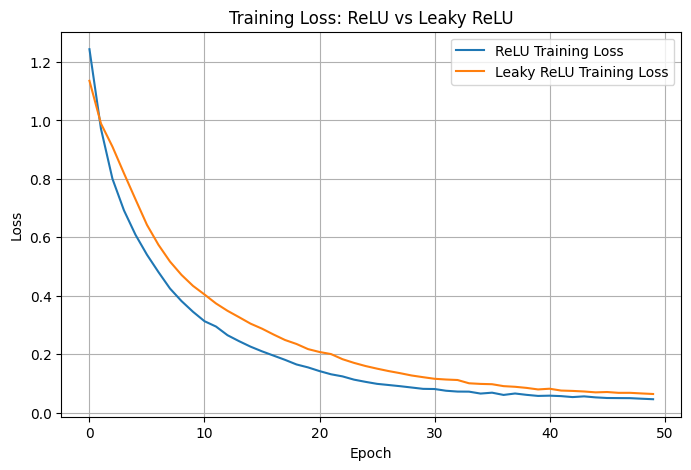

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    relu_history.history["loss"],
    label="ReLU Training Loss"
)

plt.plot(
    lrelu_history.history["loss"],
    label="Leaky ReLU Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: ReLU vs Leaky ReLU")
plt.legend()
plt.grid()
plt.show()

## 8. Compare Validation Accuracy

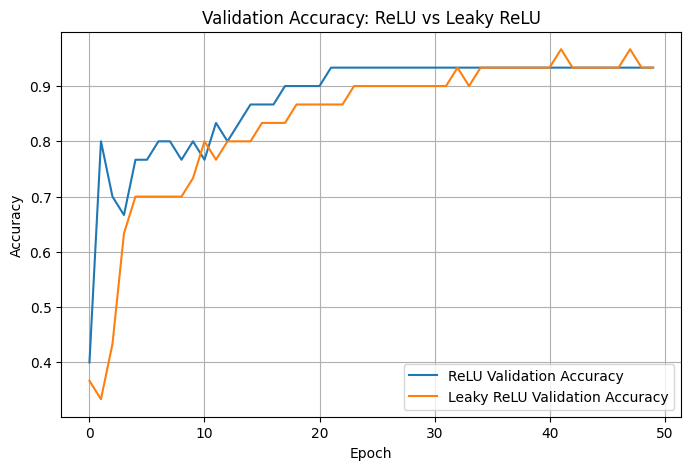

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    relu_history.history["val_accuracy"],
    label="ReLU Validation Accuracy"
)

plt.plot(
    lrelu_history.history["val_accuracy"],
    label="Leaky ReLU Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: ReLU vs Leaky ReLU")
plt.legend()
plt.grid()
plt.show()

## 9. Effect of Different `test_size` and `random_state`



In [ ]:
test_sizes = [0.2, 0.3, 0.4]
random_states = [0, 42, 100]

results = []

for test_size in test_sizes:
    for random_state in random_states:

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y_raw
        )

        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # -------------------------
        # ReLU
        # -------------------------
        relu_model = create_model("relu")

        relu_history = relu_model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            verbose=0,
            validation_data=(X_test, y_test)
        )

        relu_loss, relu_acc = relu_model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        # -------------------------
        # Leaky ReLU
        # -------------------------
        lrelu_model = create_model("lrelu")

        lrelu_history = lrelu_model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            verbose=0,
            validation_data=(X_test, y_test)
        )

        lrelu_loss, lrelu_acc = lrelu_model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        results.append([
            test_size,
            random_state,
            relu_loss,
            relu_acc,
            lrelu_loss,
            lrelu_acc
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Test Size",
        "Random State",
        "ReLU Loss",
        "ReLU Accuracy",
        "Leaky ReLU Loss",
        "Leaky ReLU Accuracy"
    ]
)

results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

,Test Size,Random State,ReLU Loss,ReLU Accuracy,Leaky ReLU Loss,Leaky ReLU Accuracy
0,0.2,0,0.040664,1.000000,0.050987,0.966667
1,0.2,42,0.075476,0.966667,0.101065,0.933333
2,0.2,100,0.306306,0.900000,0.122161,0.900000
3,0.3,0,0.077107,0.955556,0.090483,0.977778
4,0.3,42,0.152491,0.933333,0.141771,0.911111
5,0.3,100,0.145464,0.911111,0.195829,0.911111
6,0.4,0,0.087322,0.950000,0.098237,0.983333
7,0.4,42,0.102728,0.966667,0.102807,0.950000
8,0.4,100,0.238510,0.900000,0.153189,0.900000
